# EDA - Bike Sharing Demand
UE24CS352A ML Mini-Project. Goal: predict hourly `count`, metric RMSLE. Findings feed `src/features.py`.

In [2]:
%pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
train = pd.read_csv("../data/train.csv", parse_dates=["datetime"])
test = pd.read_csv("../data/test.csv", parse_dates=["datetime"])
print(train.shape, test.shape)
train.head()

(10886, 12) (6493, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 1. Structure, types, missing values

In [4]:
display(train.dtypes.to_frame("dtype").T)
print("Missing (train):", train.isna().sum().sum(), "| Missing (test):", test.isna().sum().sum())
print("Duplicated timestamps:", train.datetime.duplicated().sum())
print("Train dates:", train.datetime.min(), "->", train.datetime.max())
print("Test dates :", test.datetime.min(), "->", test.datetime.max())
print("Train days-of-month:", sorted(train.datetime.dt.day.unique())[:3], "...", train.datetime.dt.day.max())
print("Test days-of-month :", test.datetime.dt.day.min(), "...", test.datetime.dt.day.max())
train.describe().T

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
dtype,datetime64[us],int64,int64,int64,int64,float64,float64,int64,float64,int64,int64,int64


Missing (train): 0 | Missing (test): 0
Duplicated timestamps: 0
Train dates: 2011-01-01 00:00:00 -> 2012-12-19 23:00:00
Test dates : 2011-01-20 00:00:00 -> 2012-12-31 23:00:00
Train days-of-month: [np.int32(1), np.int32(2), np.int32(3)] ... 19
Test days-of-month : 20 ... 31


,count,mean,min,25%,50%,75%,max,std
datetime,10886,2011-12-27 05:56:22.399412,2011-01-01 00:00:00,2011-07-02 07:15:00,2012-01-01 20:30:00,2012-07-01 12:45:00,2012-12-19 23:00:00,NaN
season,10886.0,2.506614,1.0,2.0,3.0,4.0,4.0,1.116174
holiday,10886.0,0.028569,0.0,0.0,0.0,0.0,1.0,0.166599
workingday,10886.0,0.680875,0.0,0.0,1.0,1.0,1.0,0.466159
weather,10886.0,1.418427,1.0,1.0,1.0,2.0,4.0,0.633839
temp,10886.0,20.23086,0.82,13.94,20.5,26.24,41.0,7.79159
atemp,10886.0,23.655084,0.76,16.665,24.24,31.06,45.455,8.474601
humidity,10886.0,61.88646,0.0,47.0,62.0,77.0,100.0,19.245033
windspeed,10886.0,12.799395,0.0,7.0015,12.998,16.9979,56.9969,8.164537
casual,10886.0,36.021955,0.0,4.0,17.0,49.0,367.0,49.960477


**Note:** train = days 1-19 of each month, test = days 20+ of the same months. So this is interpolation across time, not pure forecasting.

## 2. Target distribution -> why log1p

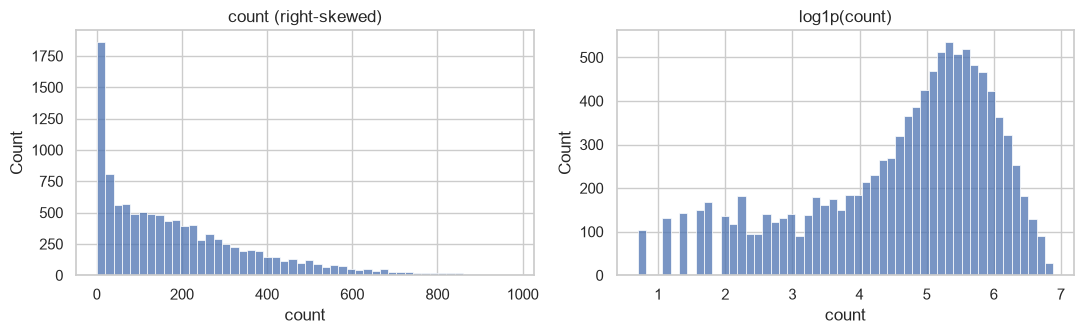

skew raw: 1.24 | skew log1p: -0.85


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(train["count"], bins=50, ax=ax[0]); ax[0].set_title("count (right-skewed)")
sns.histplot(np.log1p(train["count"]), bins=50, ax=ax[1]); ax[1].set_title("log1p(count)")
plt.tight_layout(); plt.show()
print("skew raw:", round(train["count"].skew(), 2), "| skew log1p:", round(np.log1p(train["count"]).skew(), 2))

RMSLE = RMSE on log1p, so training on `log1p(count)` directly optimises the metric and tames the skew.

In [6]:
d = train.copy()
d["hour"] = d.datetime.dt.hour; d["month"] = d.datetime.dt.month
d["dow"] = d.datetime.dt.dayofweek; d["year"] = d.datetime.dt.year
d["daytype"] = np.where(d.workingday == 1, "working day", "weekend/holiday")

## 3. Hour of day (the strongest signal)

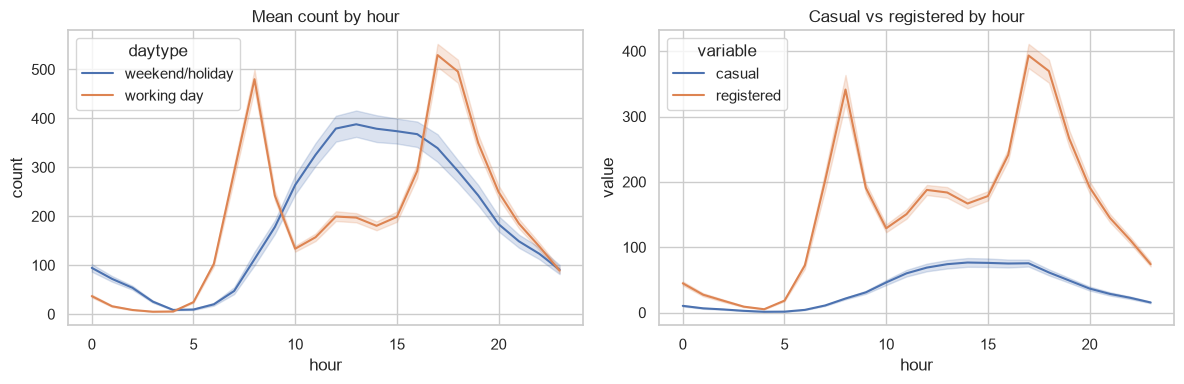

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=d, x="hour", y="count", hue="daytype", ax=ax[0]); ax[0].set_title("Mean count by hour")
sns.lineplot(data=d.melt(id_vars="hour", value_vars=["casual","registered"]), x="hour", y="value", hue="variable", ax=ax[1])
ax[1].set_title("Casual vs registered by hour"); plt.tight_layout(); plt.show()

Working days: twin commute peaks (~8am, ~5-6pm). Weekends: one broad midday hump. Registered users drive the commute peaks; casual users the weekend hump -> motivates `peak_weekday` / `peak_weekend` flags.

## 4. Month, season, year, day of week

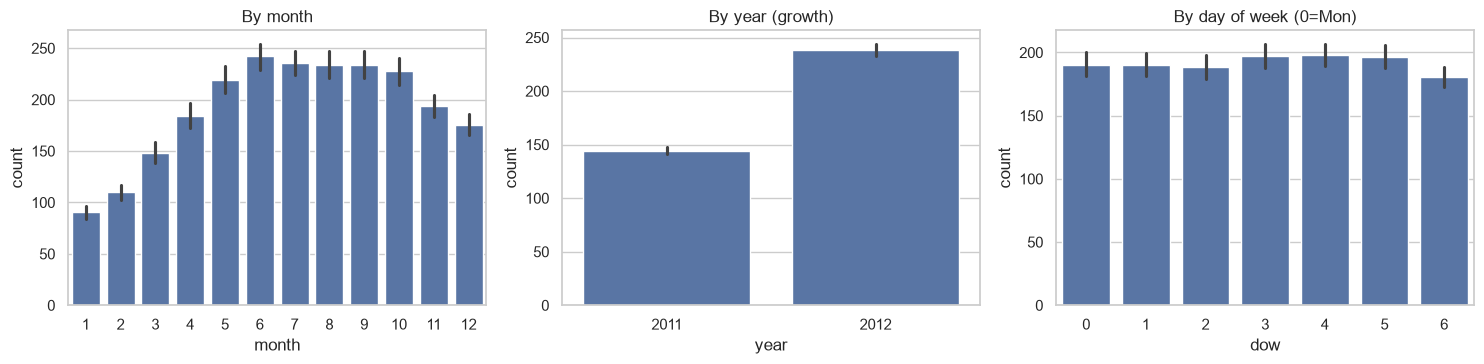

{1: 116.3, 2: 215.3, 3: 234.4, 4: 199.0}


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
sns.barplot(data=d, x="month", y="count", ax=ax[0]); ax[0].set_title("By month")
sns.barplot(data=d, x="year", y="count", ax=ax[1]); ax[1].set_title("By year (growth)")
sns.barplot(data=d, x="dow", y="count", ax=ax[2]); ax[2].set_title("By day of week (0=Mon)")
plt.tight_layout(); plt.show()
print(d.groupby("season")["count"].mean().round(1).to_dict())

## 5. Weather and temperature

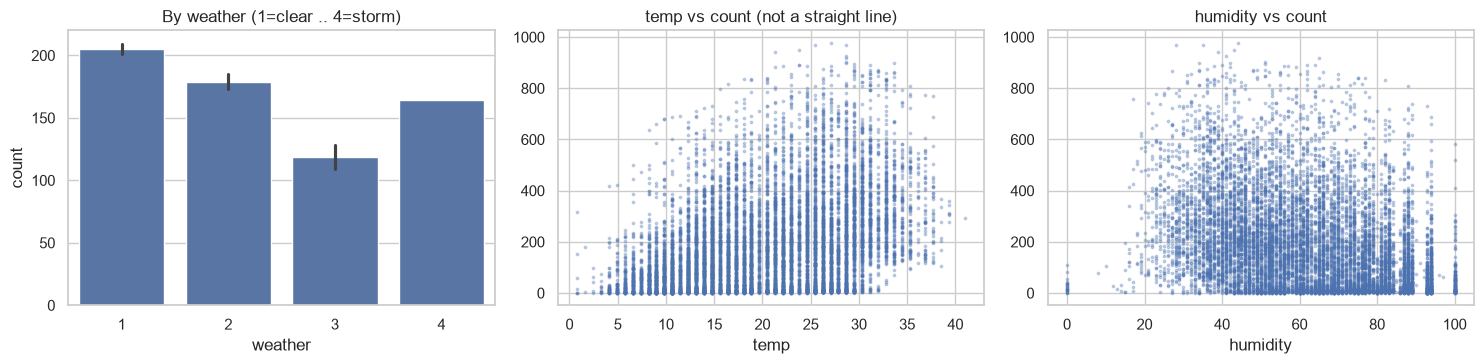

weather counts: {1: 7192, 2: 2834, 3: 859, 4: 1}


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
sns.barplot(data=d, x="weather", y="count", ax=ax[0]); ax[0].set_title("By weather (1=clear .. 4=storm)")
ax[1].scatter(d.temp, d["count"], s=3, alpha=.3); ax[1].set_title("temp vs count (not a straight line)")
ax[1].set_xlabel("temp")
ax[2].scatter(d.humidity, d["count"], s=3, alpha=.3); ax[2].set_title("humidity vs count"); ax[2].set_xlabel("humidity")
plt.tight_layout(); plt.show()
print("weather counts:", d.weather.value_counts().sort_index().to_dict())

Demand rises with temperature but flattens/drops when hot -> **temperature buckets** help linear models. Weather 4 is very rare.

## 6. Holiday and working day

In [10]:
print(d.groupby("holiday")["count"].agg(["mean", "count"]).round(1))
print(d.groupby("workingday")["count"].agg(["mean", "count"]).round(1))

          mean  count
holiday              
0        191.7  10575
1        185.9    311
             mean  count
workingday              
0           188.5   3474
1           193.0   7412


Holidays are only a small share of rows and, after accounting for hour + workingday, add little -> candidate to **drop** (tested in ablation).

## 7. Correlations / collinearity

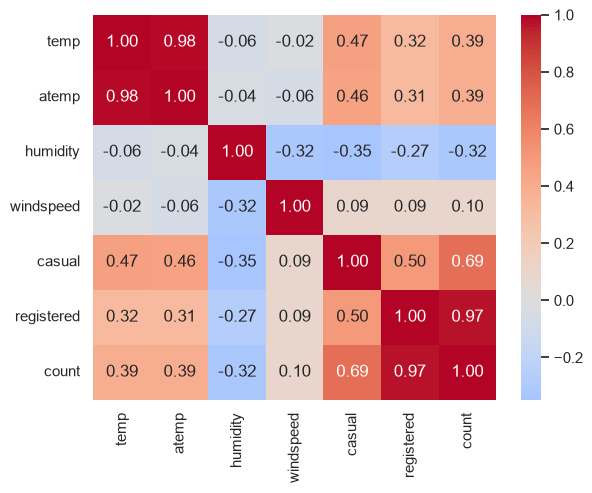

In [11]:
num = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]
plt.figure(figsize=(6.5, 5)); sns.heatmap(train[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0); plt.show()

`temp` and `atemp` are ~0.98 correlated -> collinearity for linear models; ablation tests dropping `temp`.

## 8. Outliers and oddities

windspeed == 0: 0.121 (likely missing values coded as 0)
hour     0      1     2     3     4     5      6      7      8      9   ...  \
0.50   41.0   19.0  11.0   6.0   6.0  19.0   75.0  208.0  392.0  217.0  ...   
0.99  191.0  127.0  95.0  51.0  19.0  49.0  197.0  546.0  803.0  398.0  ...   

hour     14     15     16     17     18     19     20     21     22     23  
0.50  212.0  232.0  310.0  480.0  422.0  312.0  224.0  172.0  129.0   80.0  
0.99  657.0  664.0  656.0  908.0  885.0  666.0  502.0  385.0  308.0  232.0  

[2 rows x 24 columns]


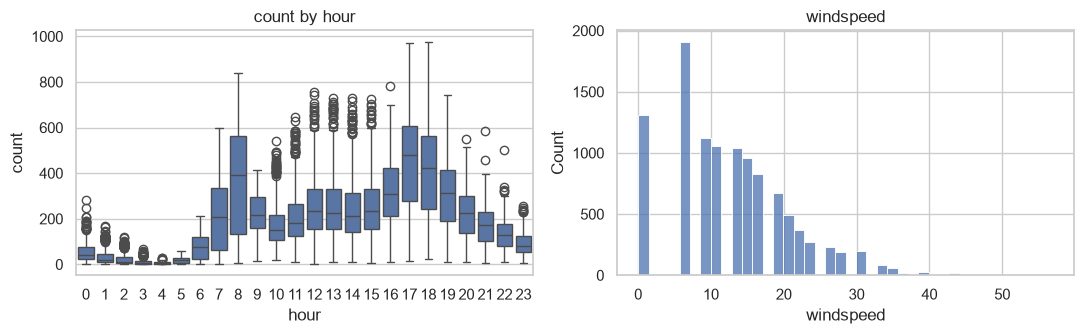

In [12]:
print("windspeed == 0:", (train.windspeed == 0).mean().round(3), "(likely missing values coded as 0)")
print(d.groupby("hour")["count"].quantile([.5, .99]).unstack().round(0).T)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(data=d, x="hour", y="count", ax=ax[0]); ax[0].set_title("count by hour")
sns.histplot(train.windspeed, bins=40, ax=ax[1]); ax[1].set_title("windspeed")
plt.tight_layout(); plt.show()

## 9. Summary -> feature decisions
- Train on `log1p(count)`, evaluate RMSLE.
- Parse datetime -> hour, month, day of week, year.
- Hour is dominant; add weekday/weekend peak flags.
- One-hot categoricals + temperature buckets for linear models.
- `temp`/`atemp` collinear; `holiday` weak -> ablation decides.
- Casual vs registered behave differently by hour -> separate-model experiment.